# Práctica 2 — Generación de Variables Aleatorias Continuas
**CC2017 Modelación y Simulación — Ciclo 2, 2026**

Notebook único de solución y verificación numérica. Todas las simulaciones usan una semilla global reproducible. Cada estimación Monte Carlo se contrasta contra su valor exacto —forma cerrada cuando existe, cuadratura de alta precisión en caso contrario— y se reporta la desviación en unidades de error estándar.

## 0. Configuración común

In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, special, stats
from IPython.display import display

SEMILLA = 20_172_026
rng = np.random.default_rng(SEMILLA)

NAVY = "#003865"
ORANGE = "#FC4C02"
GREY = "#696969"
YELLOW = "#FDB92E"
PALETA = [NAVY, ORANGE, GREY, YELLOW]

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


def tabla(df, decimales=6):
    # Tabla uniforme, sin índice, con formato numérico homogéneo.
    return df.style.hide(axis="index").format(precision=decimales, thousands=",")


def z_desviacion(estimacion, exacto, se):
    return (estimacion - exacto) / se if se > 0 else np.nan


def se_media(x):
    x = np.asarray(x, dtype=float)
    return x.std(ddof=1) / np.sqrt(x.size)


def se_proporcion(p_hat, n):
    return math.sqrt(p_hat * (1 - p_hat) / n)

print(f"Semilla global: {SEMILLA}")

Semilla global: 20172026


## 1. Ejercicio 1

**Enunciado.** Sea $X\sim\text{Exp}(1)$. Simular la condicional de $X$ dado $X<0.05$, cuya densidad es
$$f(x)=\frac{e^{-x}}{1-e^{-0.05}},\qquad 0<x<0.05 .$$
Generar 1000 variables y estimar $E[X\mid X<0.05]$; luego obtener el valor exacto.

**Método.** El camino ingenuo —generar exponenciales y descartar las que superen $0.05$— acepta con probabilidad $1-e^{-0.05}=0.04877$, es decir **20.5 exponenciales por variable aceptada**. En su lugar se usa transformación inversa sobre la condicional, que es exacta y cuesta **un solo uniforme**:
$$F(x)=\frac{1-e^{-x}}{1-e^{-0.05}}\ \Longrightarrow\ X=F^{-1}(U)=-\log\!\bigl(1-U(1-e^{-0.05})\bigr).$$

**Valor exacto.** Integrando por partes en $\int_0^a x e^{-x}dx=1-(1+a)e^{-a}$ con $a=0.05$:
$$E[X\mid X<a]=\frac{1-(1+a)e^{-a}}{1-e^{-a}} .$$

In [2]:
A1 = 0.05
NORM1 = 1 - math.exp(-A1)   # 1 - e^{-0.05}


def generar_ej1(n):
    # Transformación inversa de la exponencial truncada: 1 uniforme por variable.
    u = rng.random(n)
    return -np.log(1 - u * NORM1)

# Valor exacto y su confirmación por cuadratura de alta precisión.
exacto1 = (1 - (1 + A1) * math.exp(-A1)) / NORM1
quad1 = integrate.quad(lambda x: x * math.exp(-x), 0, A1, epsabs=1e-16, epsrel=1e-16)[0] / NORM1
assert abs(exacto1 - quad1) < 1e-12

# Las 1000 variables que pide el enunciado.
X1 = generar_ej1(1_000)
assert np.all((X1 > 0) & (X1 < A1))   # el soporte se respeta por construcción, sin rechazo

est1, se1 = X1.mean(), se_media(X1)

# Convergencia y contraste con corridas mayores.
filas = []
X1_grande = np.concatenate([X1, generar_ej1(499_000)])
for r in [1_000, 10_000, 100_000, 500_000]:
    x = X1_grande[:r]
    e, s = x.mean(), se_media(x)
    filas.append({"r": r, "Estimación MC": e, "SE": s, "Exacto": exacto1,
                  "Desviación (SE)": z_desviacion(e, exacto1, s)})
conv1 = pd.DataFrame(filas)
display(tabla(conv1, 8))

# Costo del método inverso frente al de rechazo: medido y exacto.
M1 = 1_000_000
propuestas = rng.exponential(1.0, size=M1)
n_aceptadas = np.count_nonzero(propuestas < A1)
costo_medido = M1 / n_aceptadas          # exponenciales gastadas por variable aceptada
costo_exacto = 1 / NORM1

costo1 = pd.DataFrame([
    {"Método": "Inversa truncada", "Sorteos por variable (medido)": 1.0,
     "Sorteos por variable (exacto)": 1.0, "Tasa de aceptación": 1.0},
    {"Método": "Rechazo sobre Exp(1)", "Sorteos por variable (medido)": costo_medido,
     "Sorteos por variable (exacto)": costo_exacto, "Tasa de aceptación": NORM1},
])
display(tabla(costo1, 4))

# Bondad de ajuste contra la CDF condicional exacta.
ks1 = stats.kstest(X1_grande, lambda x: (1 - np.exp(-x)) / NORM1)
print(f"KS contra F condicional: D = {ks1.statistic:.6f}, p = {ks1.pvalue:.4f}")

r,Estimación MC,SE,Exacto,Desviación (SE)
"1,000",0.02472690,0.00045849,0.02479168,-0.14127626
"10,000",0.02480315,0.00014344,0.02479168,0.07997535
"100,000",0.02479209,0.00004568,0.02479168,0.00899526
"500,000",0.02477018,0.00002040,0.02479168,-1.05336542


Método,Sorteos por variable (medido),Sorteos por variable (exacto),Tasa de aceptación
Inversa truncada,1.0000,1.0000,1.0000
Rechazo sobre Exp(1),20.4269,20.5042,0.0488


KS contra F condicional: D = 0.001233, p = 0.4325


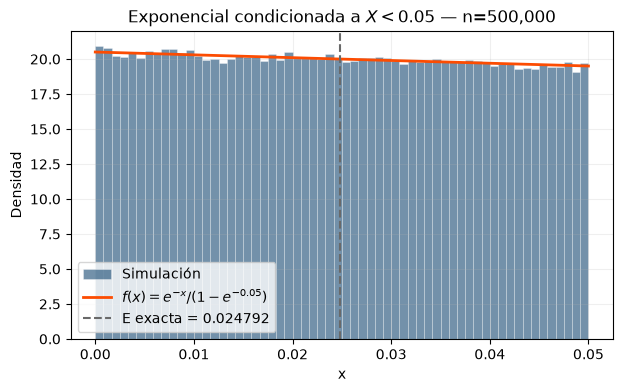

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(X1_grande, bins=60, density=True, color=NAVY, alpha=.55,
        edgecolor="white", linewidth=.4, label="Simulación")
xs = np.linspace(0, A1, 400)
ax.plot(xs, np.exp(-xs) / NORM1, linewidth=2, color=ORANGE, label=r"$f(x)=e^{-x}/(1-e^{-0.05})$")
ax.axvline(exacto1, linestyle="--", color=GREY, label=f"E exacta = {exacto1:.6f}")
ax.set_xlabel("x")
ax.set_ylabel("Densidad")
ax.set_title(f"Exponencial condicionada a $X<0.05$ — n={X1_grande.size:,}")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### Respuesta

**Algoritmo eficiente.** Generar $U\sim\text{Unif}(0,1)$ y devolver $X=-\log\bigl(1-U(1-e^{-0.05})\bigr)$: un uniforme, sin rechazo, contra las $1/(1-e^{-0.05})=\mathbf{20.5}$ exponenciales que exigiría truncar por rechazo.

**Valor exacto.**
$$\boxed{E[X\mid X<0.05]=\frac{1-1.05\,e^{-0.05}}{1-e^{-0.05}}=0.0247916753\ldots}$$

La estimación con las 1000 variables aparece en la primera fila de la tabla de convergencia, junto con su error estándar y su desviación respecto al valor exacto. Nótese que el valor está apenas por debajo de $a/2=0.025$: en un intervalo tan corto la densidad exponencial es casi uniforme.